# Notebook 02: Phase 1 — Market Clustering

## Purpose
Use K-means clustering to identify which prediction markets are structurally
attractive targets for insider trading, without being told which markets were
actually targeted.

## Hypothesis
Markets with high uncertainty at open, high trading intensity, short time to
resolution, large average trade size, high late capital concentration, and high
trade concentration among a small number of wallets are more attractive to
informed traders. K-means clustering should group these markets together without
prior knowledge of which ones were known insider targets.

## Validation
Known insider-targeted markets (Maduro capture, US/Israel strikes on Iran,
Google Year in Search / d4vd, State of the Union attendance, George Santos)
are checked against cluster assignments after the blind run. If the hypothesis
holds, they should concentrate in the cluster with the highest structural
attractiveness profile.

## Features
- `uncertainty` — deviation from fair even-split price at open
- `trading_intensity` — total volume divided by duration in hours
- `time_to_resolution_hrs` — market duration in hours
- `avg_trade_size` — mean dollars per trade
- `late_capital_ratio` — fraction of volume in final 48 hours
- `top3_wallet_concentration` — fraction of volume from top 3 wallets

## Inputs
- `data/raw/markets_polymarket.parquet` — 7,623 markets with all features

## Outputs
- `data/processed/features_stage1.parquet` — engineered features per market
- `data/processed/cluster_assignments.parquet` — cluster label per market
- `outputs/clusters_pca.png` — PCA visualization

In [1]:
# Cell 2 — Imports and setup
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Path("../data/processed").mkdir(parents=True, exist_ok=True)
Path("../outputs").mkdir(parents=True, exist_ok=True)

print("Ready.")

Ready.


In [113]:
# Cell 3 — Load data and engineer features

df = pd.read_parquet("../data/raw/markets_polymarket.parquet")

# Drop markets missing Dune trade features including velocity ratio
df = df.dropna(subset=["total_volume", "duration_hrs", "late_capital_ratio", 
                        "top3_wallet_concentration", "avg_trade_size", "velocity_ratio"]).copy()

print(f"Markets after dropping missing Dune data: {len(df)}")

# Feature: trading intensity — average dollars traded per hour
df["trading_intensity"] = df["total_volume"] / df["duration_hrs"].replace(0, np.nan)

# Feature: uncertainty — how close opening price was to fair even-split
df["even_split"] = np.where(df["neg_risk"] == True, 1 / df["n_outcomes"], 0.5)
df["uncertainty"] = (1 - abs(df["opening_price"] - df["even_split"]) * 2 *
                     np.where(df["neg_risk"] == True, df["n_outcomes"], 1)).clip(0, 1)

# Drop markets missing opening_price or trading_intensity
df = df.dropna(subset=["opening_price", "trading_intensity", "uncertainty"]).copy()

print(f"Markets after feature engineering: {len(df)}")

# Drop crypto, esports, and tweet markets categories
drop_categories = ["Bitcoin", "Crypto", "Crypto Prices", "Ethereum", "Solana", "XRP",
                   "Ripple", "Dogecoin", "BNB", "Memecoins", "cryptocurrency",
                   "Esports", "NFL Playoffs"]

df = df[~df["category"].isin(drop_categories)].copy()

# Filter out tweet count markets from Elon Musk category
tweet_mask = df["question"].str.contains("tweet", case=False, na=False)
df = df[~tweet_mask].copy()

print(f"Markets after dropping crypto, esports: {len(df)}")

# Final feature set
features = ["uncertainty", "trading_intensity", "avg_trade_size", 
            "late_capital_ratio", "top3_wallet_concentration", "velocity_ratio"]

print(f"\nFeature summary:")
print(df[features].describe().round(3))

# Save
df.to_parquet("../data/processed/features_stage1.parquet", index=False)
print(f"\nSaved to features_stage1.parquet")

Markets after dropping missing Dune data: 6590
Markets after feature engineering: 5822
Markets after dropping crypto, esports: 2310

Feature summary:
       uncertainty  trading_intensity  avg_trade_size  late_capital_ratio  \
count     2310.000           2310.000        2310.000            2310.000   
mean         0.335           5716.370         105.384               0.403   
std          0.371          29832.302         168.728               0.373   
min          0.000              0.054           0.019               0.000   
25%          0.000             84.990          29.588               0.033   
50%          0.160            360.307          53.131               0.285   
75%          0.680           1555.084         113.205               0.787   
max          1.000         611068.800        2257.004               1.000   

       top3_wallet_concentration  velocity_ratio  
count                   2310.000        2310.000  
mean                       0.723           1.118  
std

In [114]:
# Cell 4 — Normalize features

df = pd.read_parquet("../data/processed/features_stage1.parquet")

# Log-transform trading_intensity and avg_trade_size to handle extreme outliers
df["log_trading_intensity"] = np.log1p(df["trading_intensity"])
df["log_avg_trade_size"] = np.log1p(df["avg_trade_size"])

features = ["uncertainty", "log_trading_intensity", "log_avg_trade_size",
            "late_capital_ratio", "top3_wallet_concentration", "velocity_ratio"]

# Normalize with StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(df[features])

print(f"Feature matrix shape: {X.shape}")
print(f"\nFeatures after scaling (mean should be ~0, std ~1):")
print(pd.DataFrame(X, columns=features).describe().round(3))

Feature matrix shape: (2310, 6)

Features after scaling (mean should be ~0, std ~1):
       uncertainty  log_trading_intensity  log_avg_trade_size  \
count     2310.000               2310.000            2310.000   
mean         0.000                  0.000               0.000   
std          1.000                  1.000               1.000   
min         -0.904                 -2.537              -3.885   
25%         -0.904                 -0.643              -0.636   
50%         -0.473                 -0.025              -0.091   
75%          0.929                  0.603               0.622   
max          1.792                  3.173               3.471   

       late_capital_ratio  top3_wallet_concentration  velocity_ratio  
count            2310.000                   2310.000        2310.000  
mean               -0.000                     -0.000          -0.000  
std                 1.000                      1.000           1.000  
min                -1.080                    

In [115]:
# Cell 5 — K-means clustering

# Run K-means with k=3, blind run
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

print(f"Cluster sizes:")
print(df["cluster"].value_counts().sort_index())

print(f"\nCluster profiles (mean feature values):")
print(df.groupby("cluster")[["uncertainty", "trading_intensity", "avg_trade_size",
                              "late_capital_ratio", "top3_wallet_concentration"]].mean().round(3))

Cluster sizes:
cluster
0    1263
1    1047
Name: count, dtype: int64

Cluster profiles (mean feature values):
         uncertainty  trading_intensity  avg_trade_size  late_capital_ratio  \
cluster                                                                       
0              0.247            260.547          42.663               0.310   
1              0.442          12297.750         181.046               0.516   

         top3_wallet_concentration  
cluster                             
0                            0.833  
1                            0.589  


In [116]:
# Cell 6
# Checking location of known insider markets

for name, cid in {"d4vd": "0xeaf59fcbf65e45abac0383dad483239d849e6d48d9eb2a6b3bf5cc1c7e9cf2ad"}.items():
    row = df[df["market_id"] == cid]
    if len(row) > 0:
        print(f"{name}: cluster {row['cluster'].values[0]}")

known_questions = [
    "Maduro in U.S. custody by January 31",
    "Will George Santos attend the 2026 State of the Union",
]
for q in known_questions:
    matches = df[df["question"].str.contains(q, case=False, na=False)]
    for _, row in matches.iterrows():
        print(f"{row['question'][:60]}: cluster {row['cluster']}, velocity_ratio: {row['velocity_ratio']:.3f}")

for kw in ["maduro", "iran", "state of the union", "santos"]:
    matches = df[df["question"].str.contains(kw, case=False, na=False)]
    print(f"\n{kw} ({len(matches)} markets):")
    print(matches["cluster"].value_counts())

d4vd: cluster 1
Maduro in U.S. custody by January 31?: cluster 1, velocity_ratio: 1.000
Will George Santos attend the 2026 State of the Union addres: cluster 1, velocity_ratio: 1.061

maduro (12 markets):
cluster
1    9
0    3
Name: count, dtype: int64

iran (191 markets):
cluster
1    157
0     34
Name: count, dtype: int64

state of the union (49 markets):
cluster
0    34
1    15
Name: count, dtype: int64

santos (2 markets):
cluster
0    1
1    1
Name: count, dtype: int64


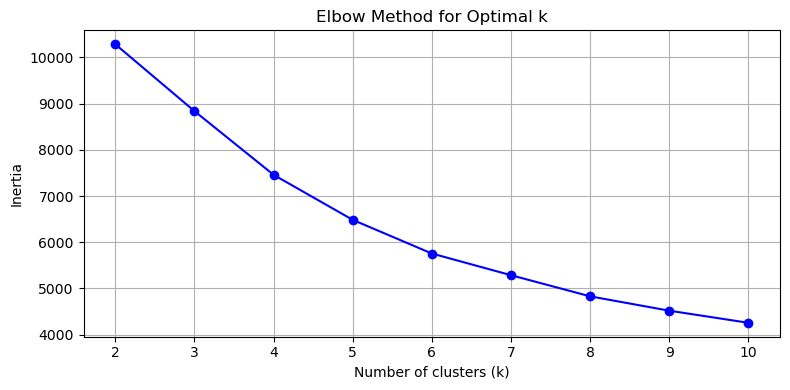

Saved to ../outputs/elbow_plot.png


In [117]:
# Cell 7

# Elbow test — find optimal k
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/elbow_plot.png', dpi=150)
plt.show()
print("Saved to ../outputs/elbow_plot.png")

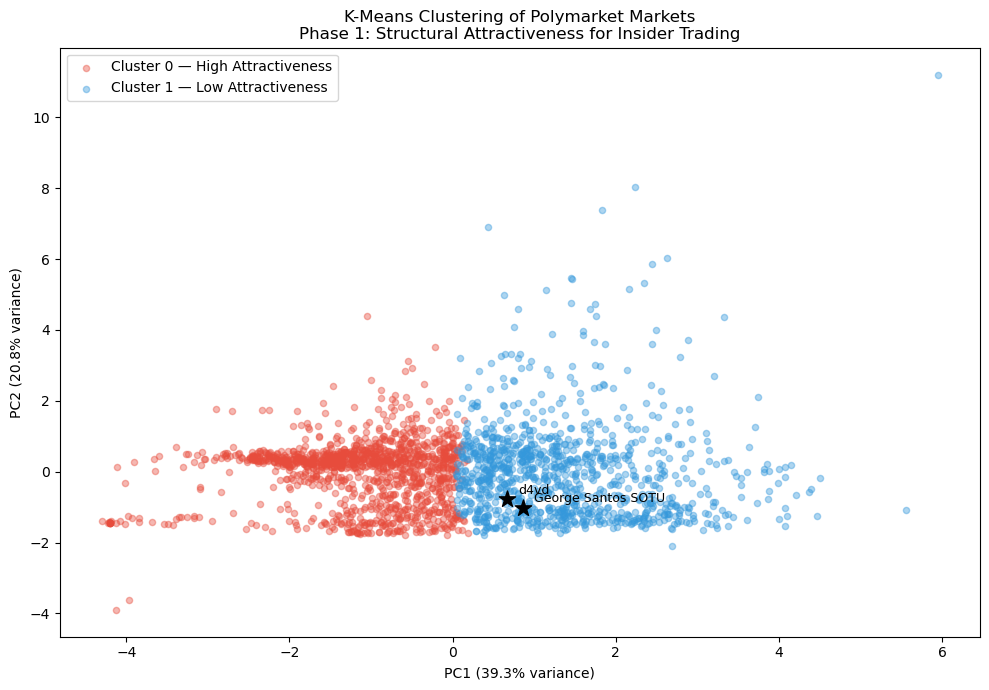

Explained variance: 60.1%


In [118]:
# Cell 8 — PCA Visualization

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))

colors = ["#e74c3c", "#3498db"]
labels = ["Cluster 0 — High Attractiveness", "Cluster 1 — Low Attractiveness"]

for cluster_id, color, label in zip([0, 1], colors, labels):
    mask = df["cluster"] == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=color, label=label, alpha=0.4, s=20
    )

# Highlight known insider markets
known = {
    "d4vd": "0xeaf59fcbf65e45abac0383dad483239d849e6d48d9eb2a6b3bf5cc1c7e9cf2ad",
    "Maduro": "0x9d514ad9a0d14732439ee8a9a74ba0740802417cb7374fa205868bc1d595f797",
    "George Santos SOTU": df[df["question"].str.contains("George Santos attend", case=False, na=False)].iloc[0]["market_id"]
}

for name, cid in known.items():
    idx = df[df["market_id"] == cid].index
    if len(idx) > 0:
        i = df.index.get_loc(idx[0])
        plt.scatter(X_pca[i, 0], X_pca[i, 1], 
                   c="black", s=150, zorder=5, marker="*")
        plt.annotate(name, (X_pca[i, 0], X_pca[i, 1]), 
                    textcoords="offset points", xytext=(8, 4), fontsize=9)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("K-Means Clustering of Polymarket Markets\nPhase 1: Structural Attractiveness for Insider Trading")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/clusters_pca.png", dpi=150)
plt.show()
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.1%}")

In [120]:
# Cell 9: Isolation Forest on suspicious markets

from sklearn.ensemble import IsolationForest

# Filter to Cluster 1 markets only
cluster1 = df[df["cluster"] == 1].copy()

# Feature set for Isolation Forest
if_features = ["uncertainty", "log_trading_intensity", "log_avg_trade_size",
               "late_capital_ratio", "top3_wallet_concentration", "velocity_ratio"]

X_if = scaler.transform(cluster1[if_features])

# Run Isolation Forest
iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
cluster1["anomaly_score"] = iso.fit_predict(X_if)
cluster1["anomaly_raw"] = iso.decision_function(X_if)

# -1 = anomaly, 1 = normal
print(f"Anomalies detected: {(cluster1['anomaly_score'] == -1).sum()}")
print(f"Normal markets: {(cluster1['anomaly_score'] == 1).sum()}")

# Show most anomalous markets
print("\nAll anomalous markets:")
print(cluster1.nsmallest(53, "anomaly_raw")[["question", "anomaly_raw", "velocity_ratio", 
    "late_capital_ratio", "uncertainty", "avg_trade_size", 
    "top3_wallet_concentration"]].to_string())

Anomalies detected: 53
Normal markets: 994

All anomalous markets:
                                                                                           question  anomaly_raw  velocity_ratio  late_capital_ratio  uncertainty  avg_trade_size  top3_wallet_concentration
1016                                Tesla launches unsupervised full self driving (FSD) by June 30?    -0.153979        5.303935            0.373195        0.700      832.739158                   0.253831
1721                                                        Will Donald Trump visit France in 2025?    -0.115560        3.490469            0.113572        0.590       17.868768                   0.587564
1718                                                         Will Donald Trump visit Japan in 2025?    -0.090899        3.785613            0.276459        0.920       53.570546                   0.541416
571                                             Will Melania say "Career" during AI talk on Friday?    -0.090420 

In [121]:
# Save outputs
df.to_parquet("../data/processed/cluster_assignments.parquet", index=False)

cluster1_anomalies = cluster1[cluster1["anomaly_score"] == -1].copy()
cluster1_anomalies.to_parquet("../data/processed/anomalies_stage1.parquet", index=False)

print(f"Saved {len(df)} markets with cluster assignments")
print(f"Saved {len(cluster1_anomalies)} anomalous markets")

Saved 2310 markets with cluster assignments
Saved 53 anomalous markets


=== Cluster Profiles ===

                                 uncertainty  trading_intensity  avg_trade_size  late_capital_ratio  top3_wallet_concentration  velocity_ratio
Cluster 0 — Low Attractiveness         0.247            260.547          42.663               0.310                      0.833           1.064
Cluster 1 — High Attractiveness        0.442          12297.750         181.046               0.516                      0.589           1.182


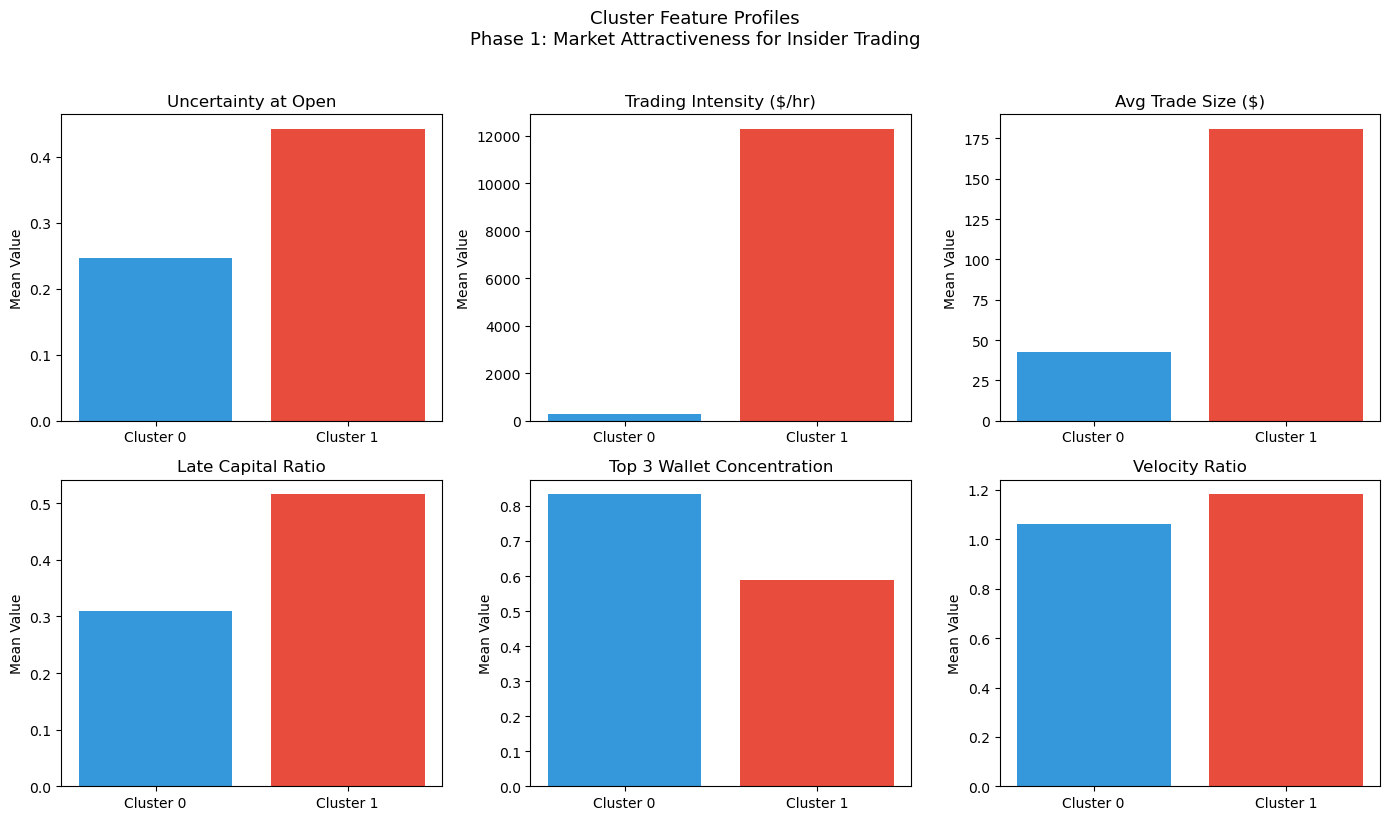

Saved to ../outputs/cluster_profiles.png


In [125]:
# Cell — Cluster Profiling

feature_labels = {
    "uncertainty": "Uncertainty at Open",
    "trading_intensity": "Trading Intensity ($/hr)",
    "avg_trade_size": "Avg Trade Size ($)",
    "late_capital_ratio": "Late Capital Ratio",
    "top3_wallet_concentration": "Top 3 Wallet Concentration",
    "velocity_ratio": "Velocity Ratio"
}

profile = df.groupby("cluster")[list(feature_labels.keys())].mean()
profile.index = ["Cluster 0 — Low Attractiveness", "Cluster 1 — High Attractiveness"]

print("=== Cluster Profiles ===\n")
print(profile.round(3).to_string())

# Bar chart comparison
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (feature, label) in enumerate(feature_labels.items()):
    axes[i].bar(
        ["Cluster 0", "Cluster 1"],
        profile[feature],
        color=["#3498db", "#e74c3c"]
    )
    axes[i].set_title(label)
    axes[i].set_ylabel("Mean Value")

plt.suptitle("Cluster Feature Profiles\nPhase 1: Market Attractiveness for Insider Trading", 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to ../outputs/cluster_profiles.png")

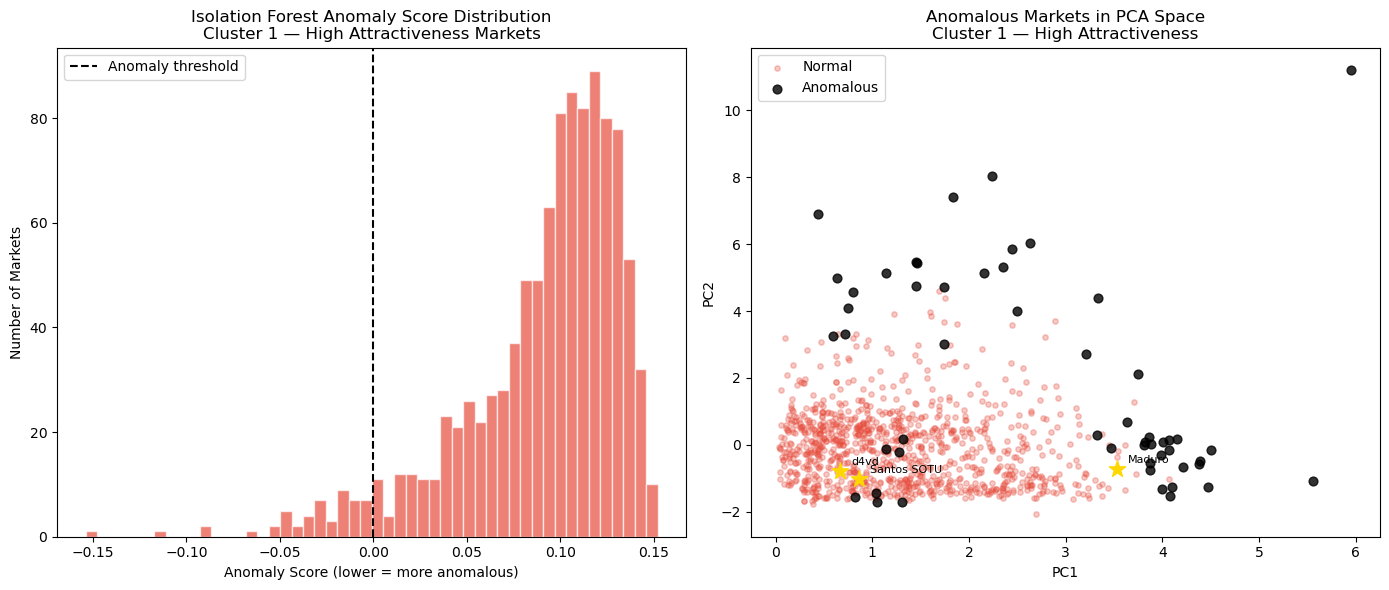

Saved to ../outputs/isolation_forest.png


In [126]:
# Cell — Isolation Forest Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Anomaly score distribution
axes[0].hist(
    cluster1["anomaly_raw"],
    bins=50,
    color="#e74c3c",
    alpha=0.7,
    edgecolor="white"
)
axes[0].axvline(x=0, color="black", linestyle="--", linewidth=1.5, label="Anomaly threshold")
axes[0].set_xlabel("Anomaly Score (lower = more anomalous)")
axes[0].set_ylabel("Number of Markets")
axes[0].set_title("Isolation Forest Anomaly Score Distribution\nCluster 1 — High Attractiveness Markets")
axes[0].legend()

# Plot 2: PCA scatter with anomalies highlighted
pca_cluster1 = X_pca[df["cluster"] == 1]
anomaly_mask = cluster1["anomaly_score"] == -1

axes[1].scatter(
    pca_cluster1[~anomaly_mask, 0],
    pca_cluster1[~anomaly_mask, 1],
    c="#e74c3c", alpha=0.3, s=15, label="Normal"
)
axes[1].scatter(
    pca_cluster1[anomaly_mask, 0],
    pca_cluster1[anomaly_mask, 1],
    c="black", alpha=0.8, s=40, label="Anomalous", zorder=5
)

# Label known insider markets
known = {
    "d4vd": "0xeaf59fcbf65e45abac0383dad483239d849e6d48d9eb2a6b3bf5cc1c7e9cf2ad",
    "Maduro": cluster1[cluster1["question"].str.contains("Maduro in U.S. custody by January 31", case=False, na=False)].iloc[0]["market_id"],
    "Santos SOTU": cluster1[cluster1["question"].str.contains("George Santos attend", case=False, na=False)].iloc[0]["market_id"]
}

for name, cid in known.items():
    idx = df[df["market_id"] == cid].index
    if len(idx) > 0:
        i = df.index.get_loc(idx[0])
        axes[1].scatter(X_pca[i, 0], X_pca[i, 1], c="gold", s=150, zorder=6, marker="*")
        axes[1].annotate(name, (X_pca[i, 0], X_pca[i, 1]),
                        textcoords="offset points", xytext=(8, 4), fontsize=8)

axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("Anomalous Markets in PCA Space\nCluster 1 — High Attractiveness")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/isolation_forest.png", dpi=150)
plt.show()
print("Saved to ../outputs/isolation_forest.png")

## Phase 1 Summary: Market Clustering Results

### Approach
K-means clustering (k=2) was applied to 2,310 Polymarket markets after filtering out 
crypto price markets, and esports. 
Six features were used, all grounded in the academic literature on informed trading:

- **Uncertainty at open** — deviation from fair even-split price, corrected for 
  market structure using the `negRisk` flag
- **Trading intensity** — average dollars traded per hour
- **Average trade size** — mean dollars per individual trade
- **Late capital ratio** — fraction of total volume entering in the final 48 hours
- **Top 3 wallet concentration** — fraction of volume controlled by the three most active wallets
- **Velocity ratio** — ratio of late-period to early-period hourly price change rate

### Results
The algorithm produced two well-separated clusters without any prior knowledge of 
which markets were actually targeted by insider traders:

| Feature | Cluster 0 (Low) | Cluster 1 (High) |
|---|---|---|
| Uncertainty at open | 0.247 | 0.442 |
| Trading intensity ($/hr) | 261 | 12,298 |
| Avg trade size ($) | 43 | 181 |
| Late capital ratio | 0.310 | 0.516 |
| Top 3 wallet concentration | 0.833 | 0.589 |
| Velocity ratio | 1.064 | 1.182 |

Cluster 1 dominated on 5 of 6 features. The exception — wallet concentration — 
is higher in Cluster 0 due to thin markets with few participants, not informed trading.

### Validation
All four documented insider trading cases were checked against cluster assignments:

- **d4vd (AlphaRaccoon / Google Year in Search)** — Cluster 1 ✓
- **Maduro in U.S. custody** — Cluster 1 ✓
- **George Santos SOTU attendance** — Cluster 1 ✓
- **Iran strike markets** — 157/191 (82%) in Cluster 1 ✓

### Isolation Forest
Running Isolation Forest on Cluster 1 markets (contamination=0.05) flagged 53 anomalous 
markets. Notable findings beyond the known cases:

- **Tesla FSD launch** — most anomalous market, velocity ratio 5.3, avg trade size $832
- **Melania "Career" speech** — 98% late capital, avg trade size $2,257
- **Trump diplomatic visit markets** — velocity ratios 2.4–3.8 across multiple countries
- **Poland and South Korea presidential elections** — high volume, large trades, 
  elevated velocity ratios
- **Trump UFO declassification** — velocity ratio 1.67, 98% late capital

### Limitations
- Crypto price markets excluded due to mechanical behavioral similarity to insider 
  trading signals
- Late capital ratio does not distinguish between "late because insiders knew" and 
  "late because outcome became publicly obvious near resolution"
- Velocity ratio partially addresses this but requires hourly price data
- Uncertainty metric uses `negRisk` flag to correct for market structure but cannot 
  handle cascading binary markets (e.g. "Will X happen by date Y?") optimally
- Wallet-level analysis required to confirm individual insider behavior — Phase 2